Simulating β = 0.25...
Simulating β = 0.5...
Critical time t_c (directed) for β = 0.5 ≈ 6.8017


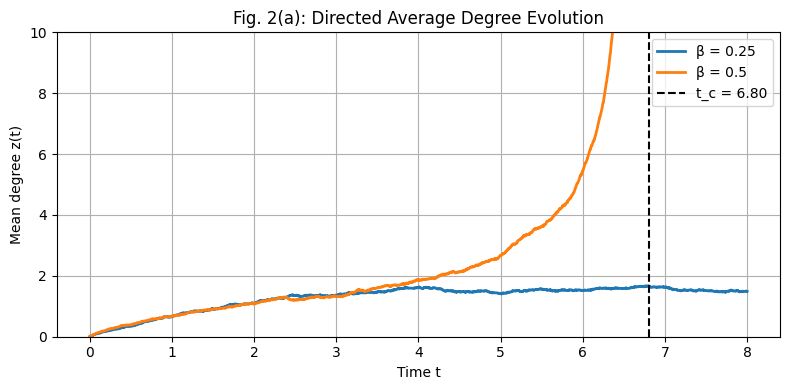

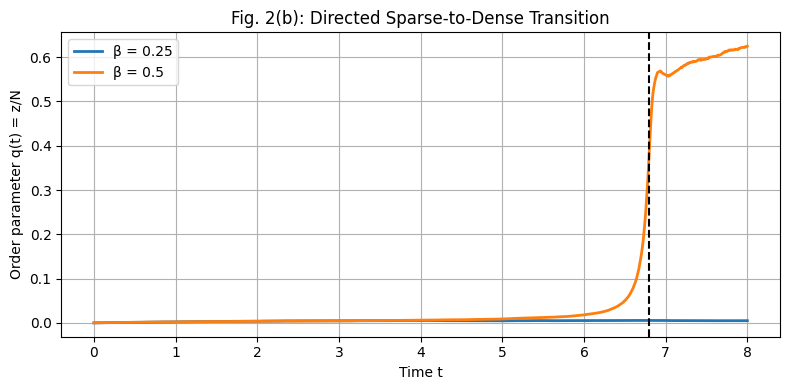

Directed density before tc: 0.0023411371237458192
Directed density near tc:   0.05608695652173913
Directed density after tc:  0.557469342251951


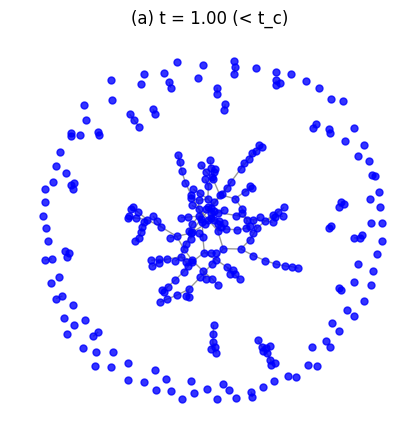

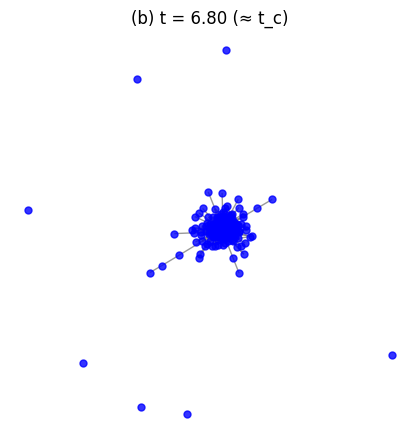

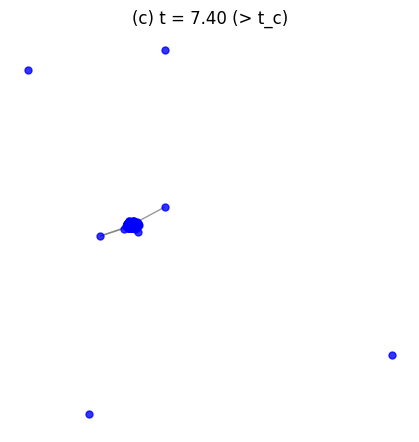

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

"""
============================================================
Exact Implementation of the DPT Model (Directed) from the Paper
============================================================
This code follows the paper exactly:

- Dynamics given by Eq. (2a) and (2b):
    W[A_ij:0→1] = α/N + β (A²)_ij
    W[A_ij:1→0] = γ
- Snapshots t < tc, t ≈ tc, t > tc

============================================================
"""

# ---------------- Parameters ----------------
N = 300
alpha = 1.0
gamma = 1.0
beta_values = [0.25, 0.5]
dt = 0.002
Tmax = 8.0
steps = int(Tmax / dt)
times = np.linspace(0, Tmax, steps)

np.random.seed(0)

# ------------- Directed Density Function -------------
def directed_density(A):
    possible = N * (N - 1)      # directed edges allowed
    actual = A.sum()
    return actual / possible

# ------------- Simulation per Eq. (2a,b) -------------
def simulate_dpt(alpha, beta, gamma, N, Tmax, dt):
    A = np.zeros((N, N), dtype=np.int8)
    np.fill_diagonal(A, 0)
    steps = int(Tmax / dt)
    times = np.linspace(0, Tmax, steps)
    z_hist = np.zeros(steps)

    for k, t in enumerate(times):
        A2 = A @ A
        P_add = (alpha / N) + beta * A2
        R_add = np.random.rand(N, N)
        R_rem = np.random.rand(N, N)
        add_mask = (A == 0) & (R_add < P_add * dt)
        rem_mask = (A == 1) & (R_rem < gamma * dt)
        A[add_mask] = 1
        A[rem_mask] = 0
        np.fill_diagonal(A, 0)
        z_hist[k] = A.sum() / N

    return times, z_hist, A

# ------------------- Run Simulations -------------------
results = {}
for beta in beta_values:
    print(f"Simulating β = {beta}...")
    times, z_hist, A_final = simulate_dpt(alpha, beta, gamma, N, Tmax, dt)
    results[beta] = {
        'times': times,
        'z_hist': z_hist,
        'A_final': A_final
    }

# ------------------- Detect Critical Time -------------------
z_hist_05 = results[0.5]['z_hist']
dz_dt = np.gradient(z_hist_05, dt)
tc_index = np.argmax(dz_dt)
tc_value = results[0.5]['times'][tc_index]
print(f"Critical time t_c (directed) for β = 0.5 ≈ {tc_value:.4f}")

# ------------------- Plot Fig. 2(a): z(t) -------------------
plt.figure(figsize=(8,4))
plt.plot(results[0.25]['times'], results[0.25]['z_hist'], lw=2, label='β = 0.25')
plt.plot(results[0.5]['times'],  results[0.5]['z_hist'], lw=2, label='β = 0.5')
plt.axvline(tc_value, linestyle='--', color='k', label=f"t_c = {tc_value:.2f}")

plt.xlabel('Time t')
plt.ylabel('Mean degree z(t)')
plt.title('Fig. 2(a): Directed Average Degree Evolution')

plt.ylim(0, 10)      # <-- set y-axis limit

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------- Plot Fig. 2(b): q(t) -------------------
plt.figure(figsize=(8,4))
for beta in beta_values:
    q_hist = results[beta]['z_hist'] / N
    plt.plot(results[beta]['times'], q_hist, lw=2, label=f'β = {beta}')
plt.axvline(tc_value, linestyle='--', color='k')
plt.xlabel('Time t')
plt.ylabel('Order parameter q(t) = z/N')
plt.title('Fig. 2(b): Directed Sparse-to-Dense Transition')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------ Fig. 1 Snapshots ------------------
beta = 0.5
A = np.zeros((N, N), dtype=np.int8)
np.fill_diagonal(A, 0)
A_before = None
A_near = None
A_after = None


for k, t in enumerate(times):
    A2 = A @ A
    P_add = (alpha / N) + beta * A2
    R_add = np.random.rand(N, N)
    R_rem = np.random.rand(N, N)
    add_mask = (A == 0) & (R_add < P_add * dt)
    rem_mask = (A == 1) & (R_rem < gamma * dt)
    A[add_mask] = 1
    A[rem_mask] = 0
    np.fill_diagonal(A, 0)

    if abs(t - 1.0) < dt/2:        A_before = A.copy()
    if abs(t - tc_value) < dt/2:   A_near = A.copy()
    if abs(t - (tc_value+0.6)) < dt/2: A_after = A.copy()

# Fallbacks
A_before = A_before if A_before is not None else A.copy()
A_near   = A_near   if A_near   is not None else A.copy()
A_after  = A_after  if A_after  is not None else A.copy()

# ---- Directed Density Print ----
print("Directed density before tc:", directed_density(A_before))
print("Directed density near tc:  ", directed_density(A_near))
print("Directed density after tc: ", directed_density(A_after))

# ------------------ Visualization ------------------
def plot_snapshot(A_mat, title):
    Und = ((A_mat + A_mat.T) > 0).astype(int)   # positions use undirected
    G = nx.from_numpy_array(Und)
    plt.figure(figsize=(4,4))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, node_size=25, edge_color='gray', node_color='blue', alpha=0.8)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_snapshot(A_before, f"(a) t = 1.00 (< t_c)")
plot_snapshot(A_near,   f"(b) t = {tc_value:.2f} (≈ t_c)")
plot_snapshot(A_after,  f"(c) t = {tc_value+0.6:.2f} (> t_c)")


In [3]:
def get_gcc_adjacency(A_mat):
    # Convert to undirected for GCC computation
    Und = ((A_mat + A_mat.T) > 0).astype(int)
    G = nx.from_numpy_array(Und)

    # Get connected components (sorted by size)
    components = sorted(nx.connected_components(G), key=len, reverse=True)

    gcc_nodes = list(components[0])
    gcc_nodes_sorted = sorted(gcc_nodes)

    # Extract GCC adjacency matrix
    A_gcc = A_mat[np.ix_(gcc_nodes_sorted, gcc_nodes_sorted)]
    return A_gcc, components

def get_all_component_adj(A_mat):
    Und = ((A_mat + A_mat.T) > 0).astype(int)
    G = nx.from_numpy_array(Und)

    components = list(nx.connected_components(G))
    component_adj_list = []

    for comp in components:
        nodes = sorted(comp)
        A_comp = A_mat[np.ix_(nodes, nodes)]
        component_adj_list.append((nodes, A_comp))

    return component_adj_list

print("\n===== GCC Adjacency Matrices =====")

A_before_gcc, comps_before = get_gcc_adjacency(A_before)
A_near_gcc,   comps_near   = get_gcc_adjacency(A_near)
A_after_gcc,  comps_after  = get_gcc_adjacency(A_after)

print("Before t_c: GCC size =", A_before_gcc.shape[0])
print("Near t_c:   GCC size =", A_near_gcc.shape[0])
print("After t_c:  GCC size =", A_after_gcc.shape[0])

print("\n===== ALL CLUSTERS (connected components) =====")

clusters_before = get_all_component_adj(A_before)
clusters_near   = get_all_component_adj(A_near)
clusters_after  = get_all_component_adj(A_after)

print("Before t_c:", [A.shape[0] for _,A in clusters_before])
print("Near t_c:",   [A.shape[0] for _,A in clusters_near])
print("After t_c:",  [A.shape[0] for _,A in clusters_after])



===== GCC Adjacency Matrices =====
Before t_c: GCC size = 145
Near t_c:   GCC size = 293
After t_c:  GCC size = 296

===== ALL CLUSTERS (connected components) =====
Before t_c: [1, 145, 1, 3, 1, 1, 1, 3, 2, 1, 5, 1, 1, 3, 1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 6, 1, 9, 1, 1, 1, 3, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 3, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Near t_c: [293, 1, 1, 1, 1, 1, 1, 1]
After t_c: [296, 1, 1, 1, 1]


In [4]:
import numpy as np

# ---- Save GCC adjacency matrices ----
np.savetxt("A_before_GCC.csv", A_before_gcc, delimiter=",", fmt="%d")
np.savetxt("A_near_GCC.csv",   A_near_gcc,   delimiter=",", fmt="%d")
np.savetxt("A_after_GCC.csv",  A_after_gcc,  delimiter=",", fmt="%d")

print("GCC adjacency matrices saved:")
print(" - A_before_GCC.csv")
print(" - A_near_GCC.csv")
print(" - A_after_GCC.csv")
def save_component_adj(cluster_list, prefix):
    for idx, (nodes, A_comp) in enumerate(cluster_list):
        fname = f"{prefix}_cluster_{idx}.csv"
        np.savetxt(fname, A_comp, delimiter=",", fmt="%d")
    print(f"Saved {len(cluster_list)} cluster adjacency matrices for: {prefix}")

# Save all clusters
save_component_adj(clusters_before, "before")
save_component_adj(clusters_near,   "near")
save_component_adj(clusters_after,  "after")


GCC adjacency matrices saved:
 - A_before_GCC.csv
 - A_near_GCC.csv
 - A_after_GCC.csv
Saved 111 cluster adjacency matrices for: before
Saved 8 cluster adjacency matrices for: near
Saved 5 cluster adjacency matrices for: after
